# Reproduce the paper figures

This notebook runs the production figure scripts on the sample dataset
(`data/sample/parametric_sample.h5`) or the file pointed to by `GPU_EHL_DATA`. 

If using the sample data in the repo the grid is not fully populated. Point the
notebook to the full dataset (`GPU_EHL_DATA`) to see the complete map. 

We recommend downloading the full dataset `parametric_sweep_final.h5` from Zenodo because if not the images in the paper will only appear partially. Thus, to reproduce the figures on the complete parameter study, set the dataset path before re-running the notebook:

```bash
export GPU_EHL_DATA=/path_to/full_dataset.h5
```


Each script writes a PDF to `paper/figures/output/`; the notebook then rasterizes
the first page to PNG for inline display.

Joaquin Garcia-Suarez (joquin.garciasuarez@epfl.ch), 2026.



In [1]:
import os
import subprocess
import sys
from pathlib import Path

import fitz
from IPython.display import Image, display

# Resolve repository root whether the notebook is run from repo root or from notebooks/
repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

script_dir = repo_root / "paper" / "figures" / "scripts"
out_dir = repo_root / "paper" / "figures" / "output"
out_dir.mkdir(parents=True, exist_ok=True)


def make_figure(script_name: str, output_name: str) -> Path:
    """Run a figure script and return the generated PDF path."""
    pdf_path = out_dir / output_name
    cmd = [
        sys.executable,
        str(script_dir / script_name),
        "--no-show",
        "--output", str(pdf_path),
    ]
    subprocess.run(cmd, check=True)
    return pdf_path


def show_pdf(pdf_path: Path, zoom: int = 2) -> None:
    """Display the first page of a PDF as a PNG raster."""
    doc = fitz.open(pdf_path)
    page = doc.load_page(0)
    pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom))
    display(Image(data=pix.tobytes("png")))
    doc.close()


## Restitution map

The coefficient of restitution is defined as

$$
e = -\frac{V_{\infty}}{V_{\rm 0}},
$$

where $V_{0}$ is the imposed impact velocity and $V(t_{\infty})$ is the
velocity at the end of the rebound. Panels show $e$ in the $(\mathrm{St}, n)$
plane, the normalized contact time, and the normalized maximum force.


Saved: /home/aj/Desktop/Work/gpu-ehl-rest-coeff/paper/figures/output/restitution_map.pdf


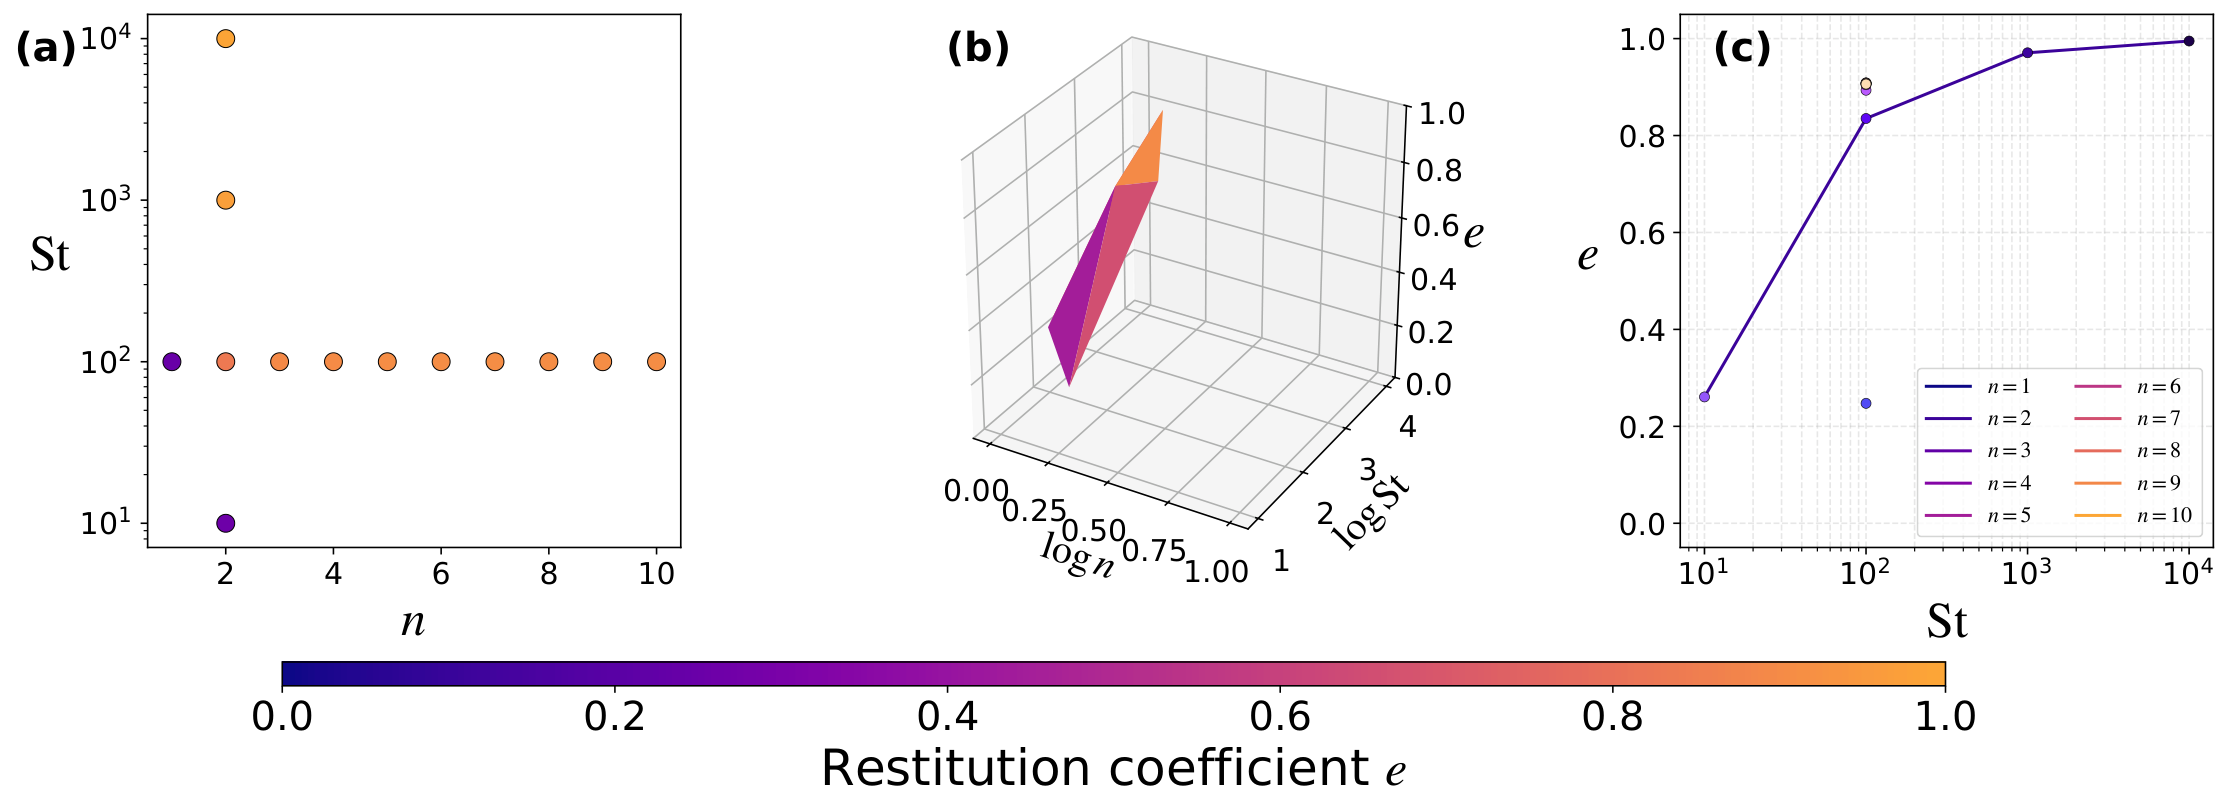

In [2]:
pdf = make_figure("fig_restitution_map.py", "restitution_map.pdf")
show_pdf(pdf)

## Gap and pressure profiles at maximum spreading

Radial profiles of the gap $h(r, t)$ and pressure $p(r,t)$ at the middle instant of the approach phase ($t/\tau = 1.66$),
colored by shape exponent $n$.


Saved: /home/aj/Desktop/Work/gpu-ehl-rest-coeff/paper/figures/output/profiles_approach_spread.pdf


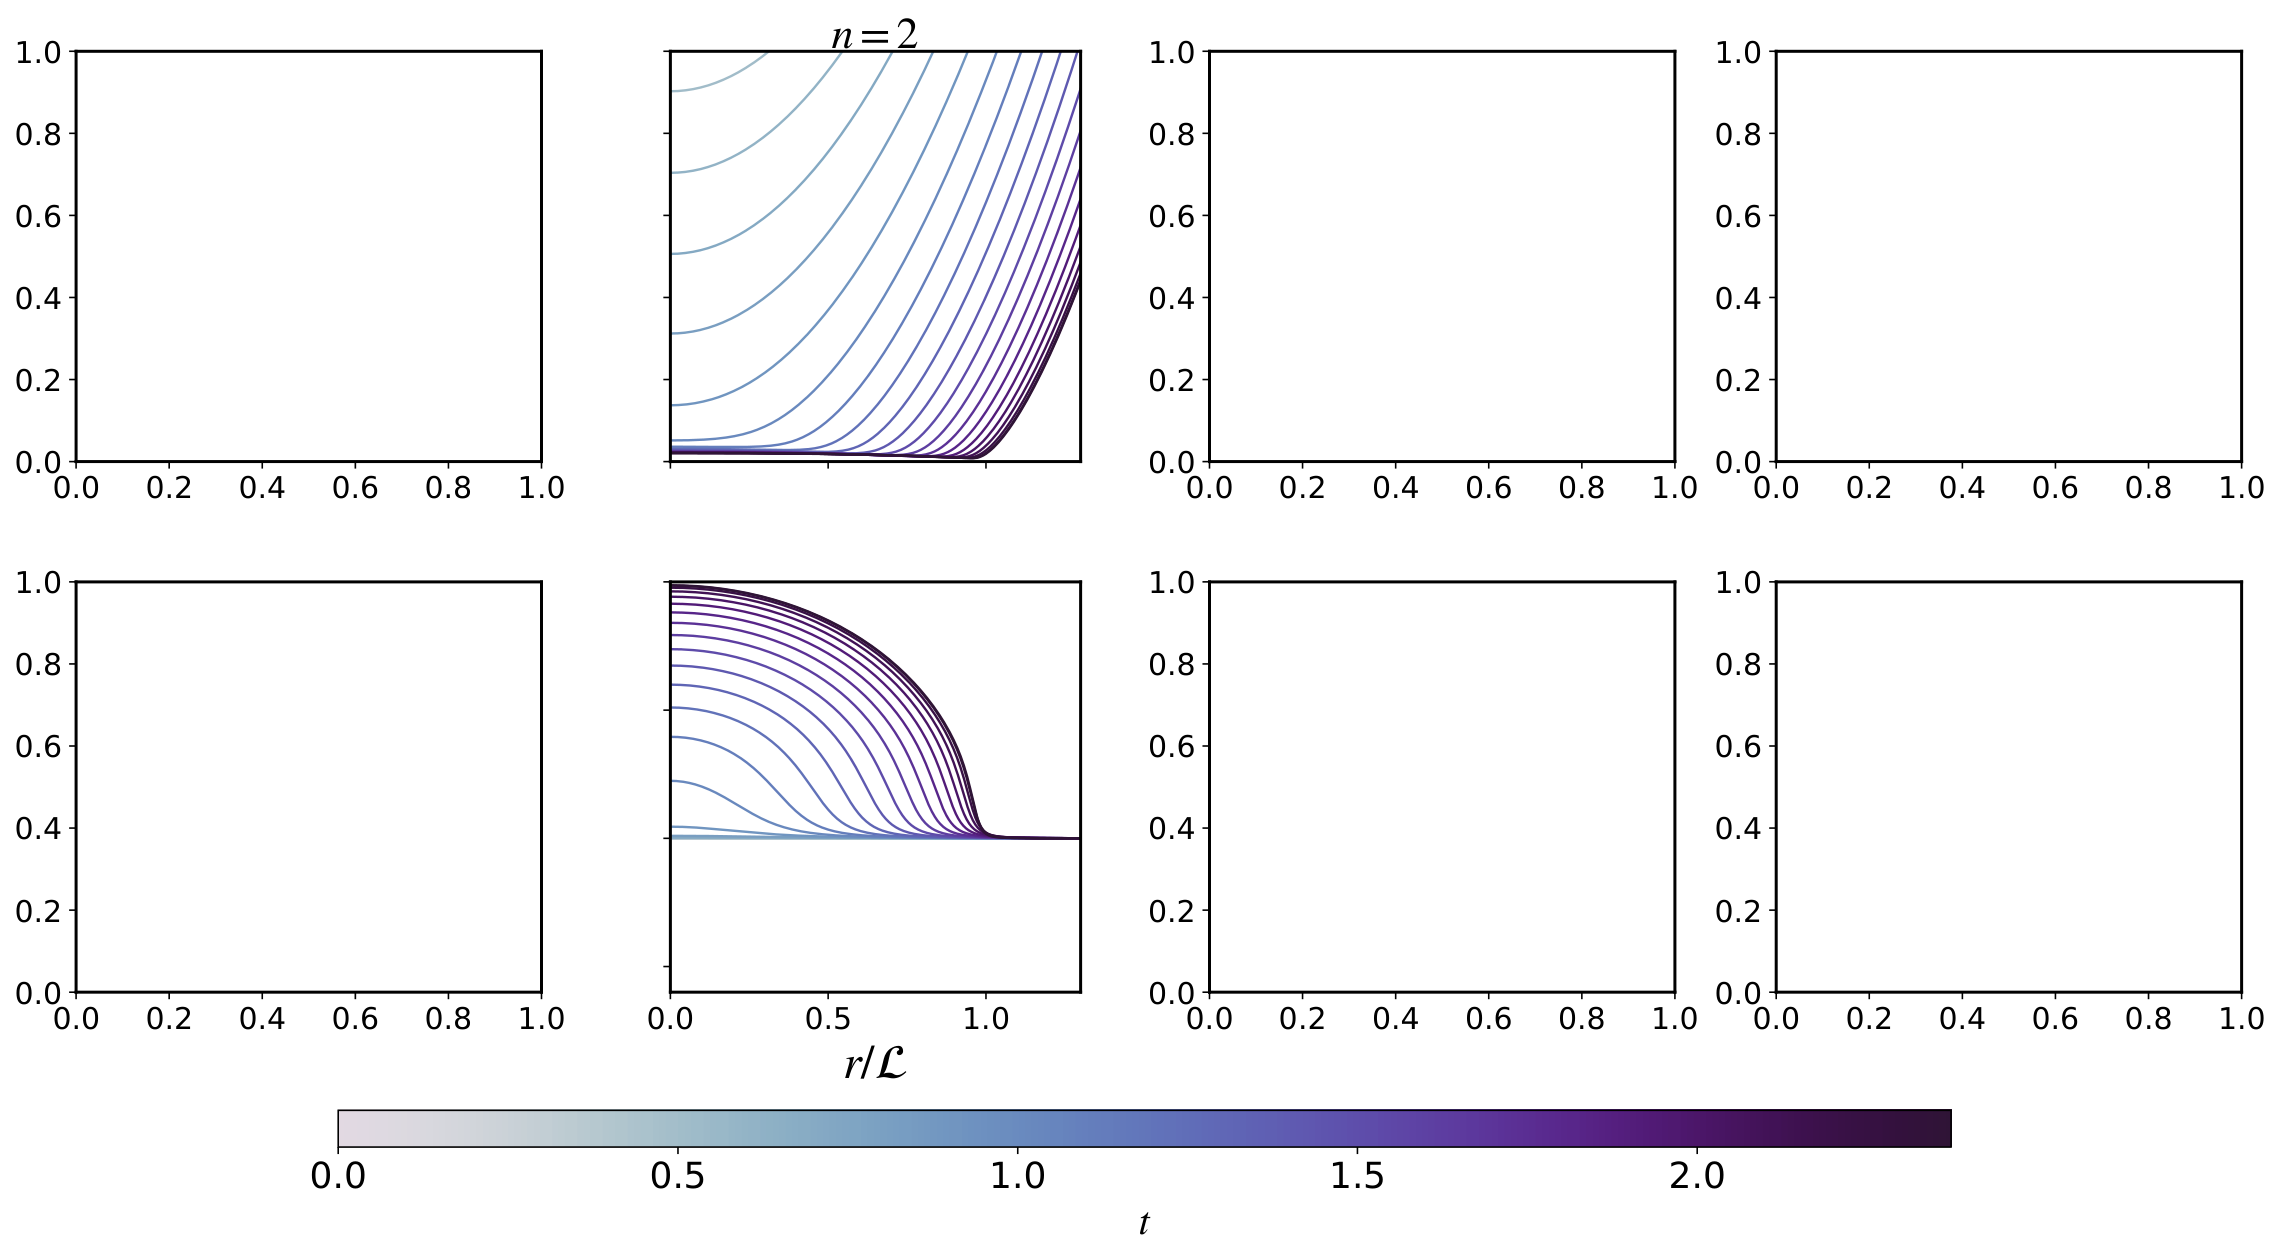

In [3]:
pdf = make_figure("fig_profiles_approach_spread.py", "profiles_approach_spread.pdf")
show_pdf(pdf)

## Energy budget over time
 
Evolution of kinetic, elastic, and dissipated components. The governing balance
reads

$$
\begin{align}
\frac{d}{dt}\bigl(K + U\bigr) &= -\mathcal{D},
\end{align}
$$

where $K$ is kinetic energy, $U$ elastic stored energy, and $\mathcal{D}$ the
viscous dissipation rate.


Saved: /home/aj/Desktop/Work/gpu-ehl-rest-coeff/paper/figures/output/energy_budget.pdf


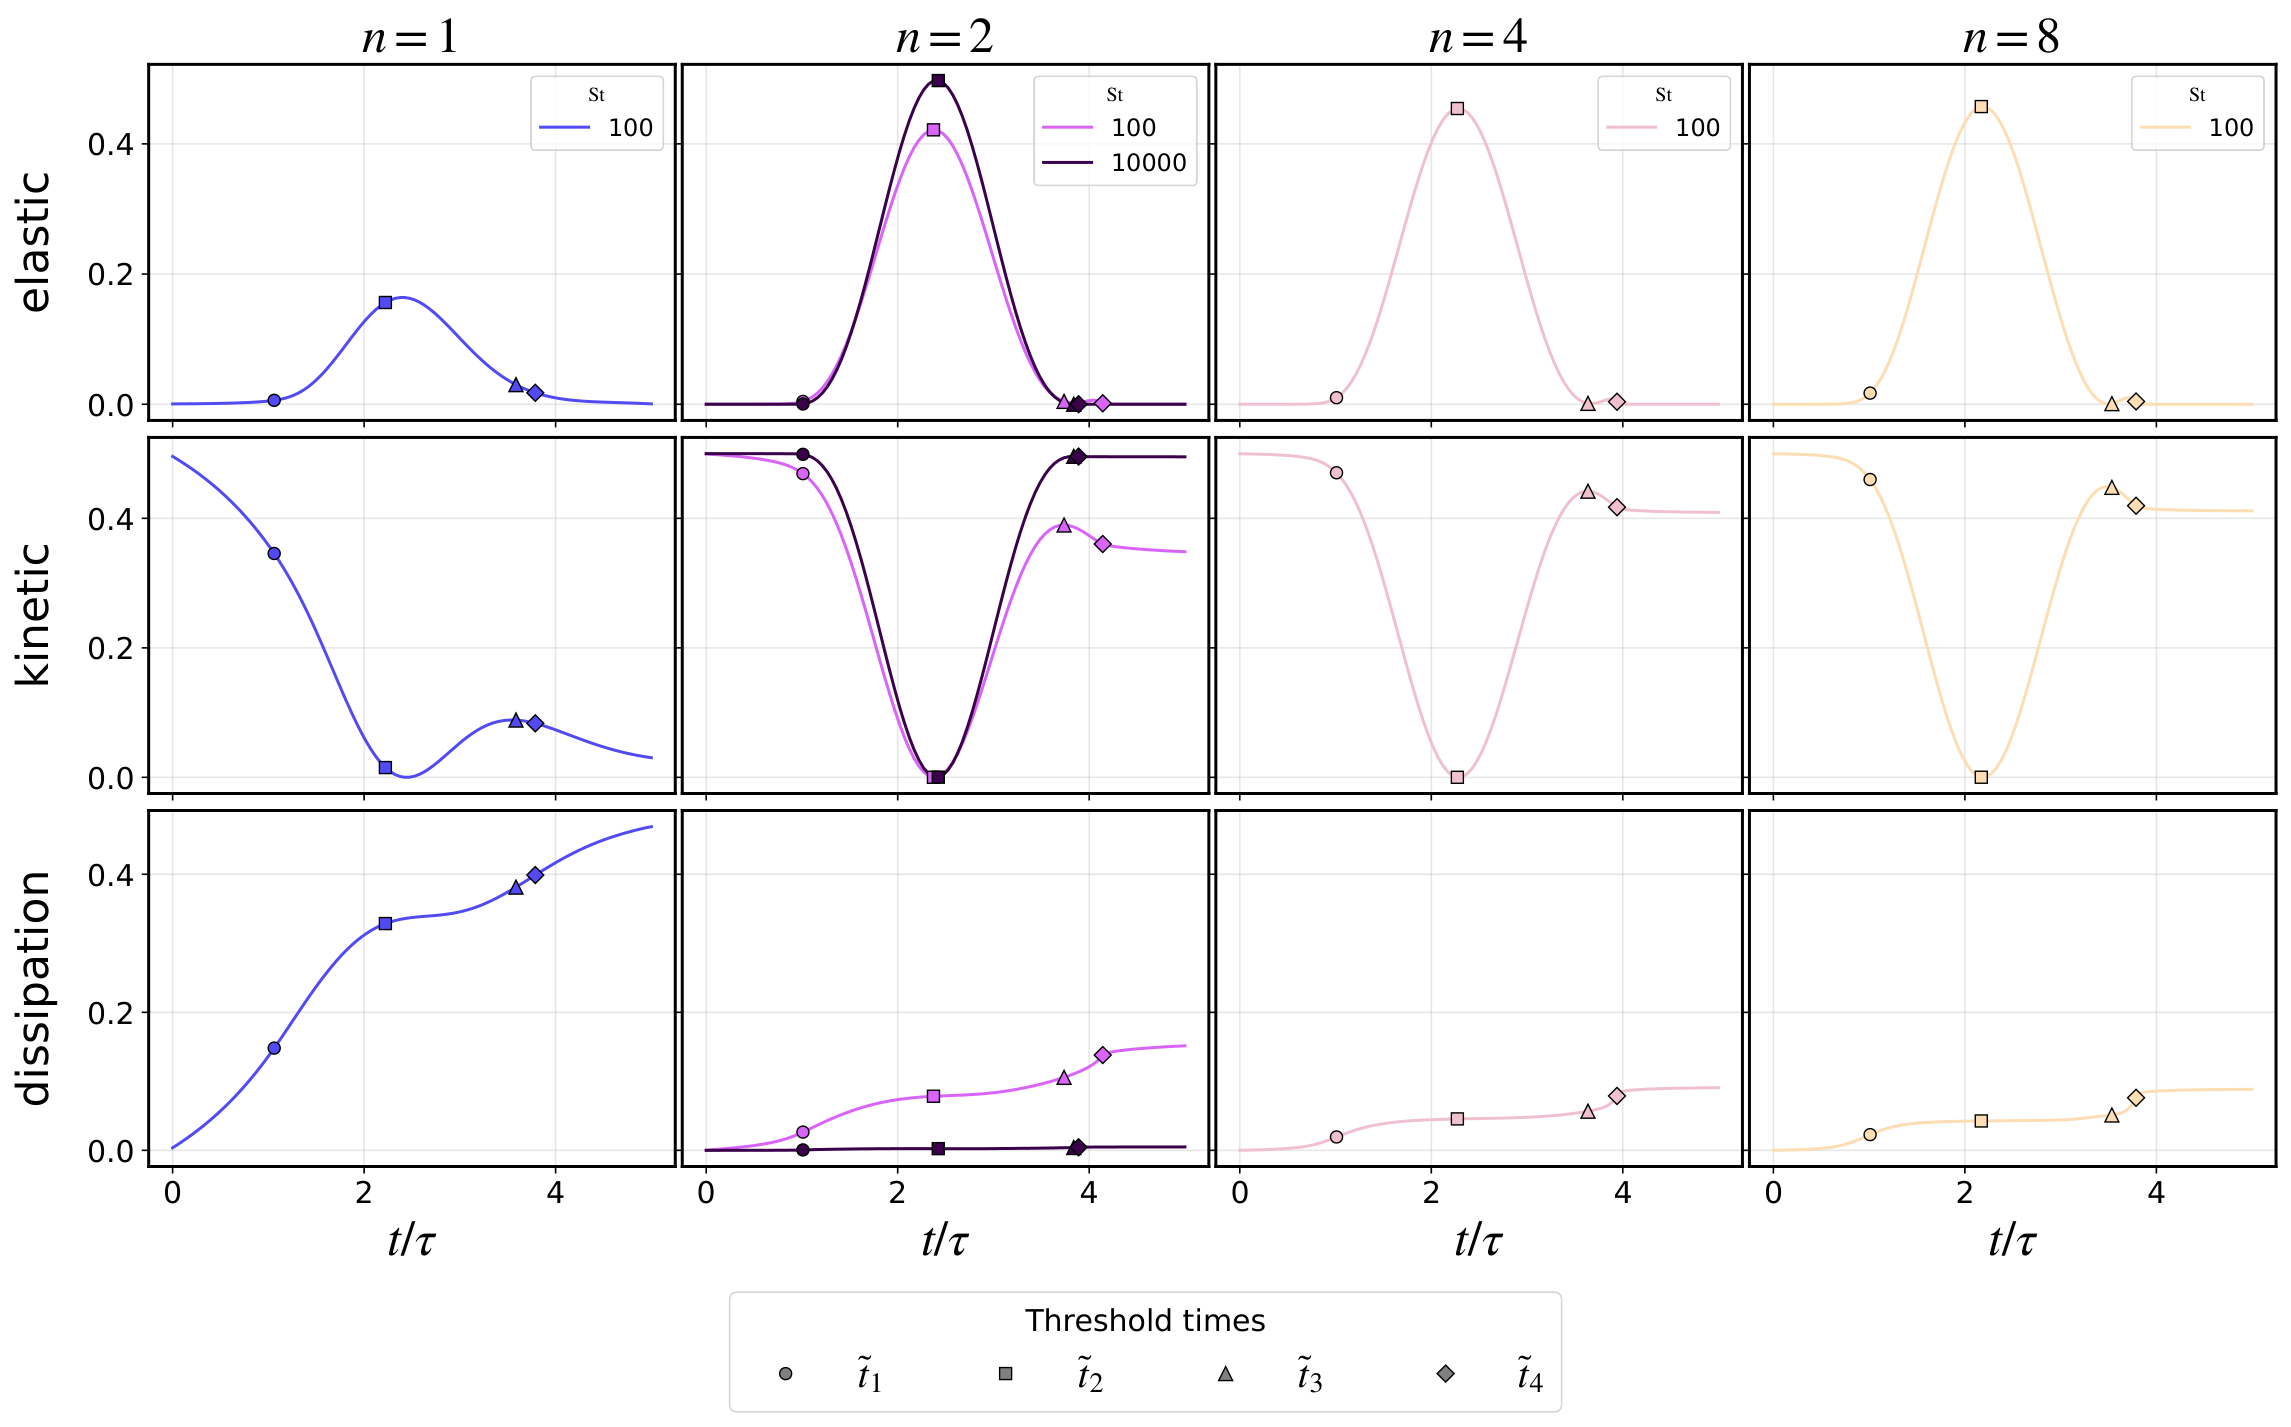

In [4]:
pdf = make_figure("fig_energy_budget.py", "energy_budget.pdf")
show_pdf(pdf)

## Time series for a representative impact

Gap $D(t)$, velocity $V(t)$, force $F(t)$, and cumulative energies for a single
$(n, \mathrm{St})$ case.


Saved: /home/aj/Desktop/Work/gpu-ehl-rest-coeff/paper/figures/output/time_series.pdf


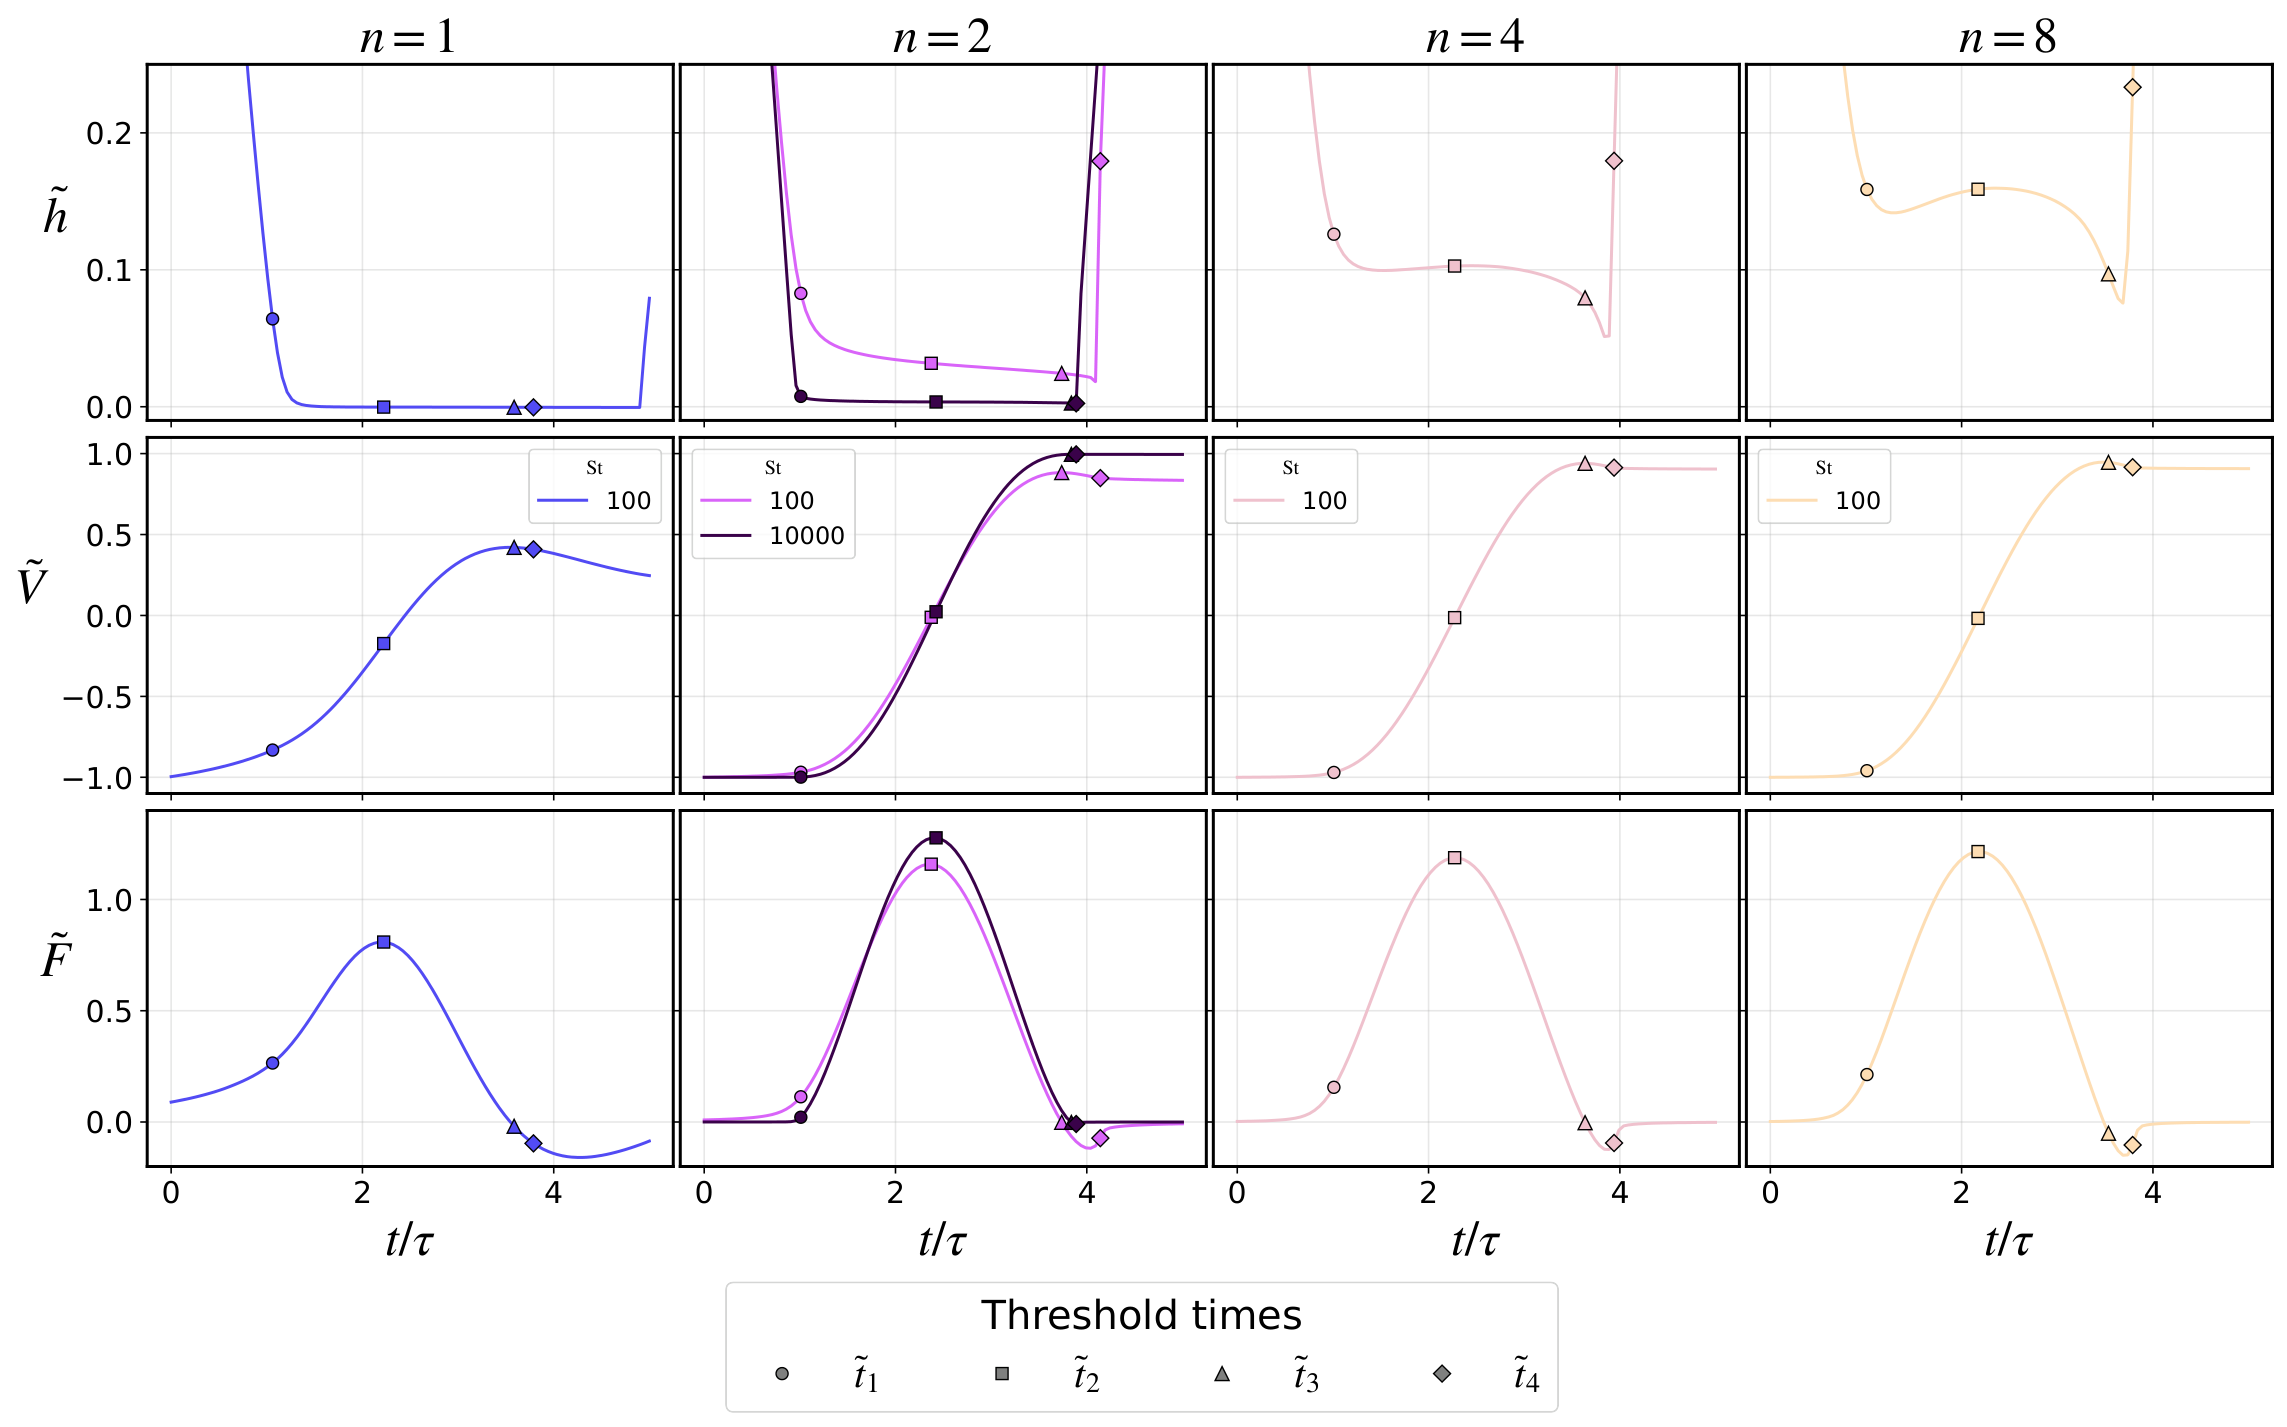

In [5]:
pdf = make_figure("fig_time_series.py", "time_series.pdf")
show_pdf(pdf)

## Central gap versus Stokes

The central gap $h(r=0,t)$ as a function of Stokes number for several shape
exponents.


Saved: /home/aj/Desktop/Work/gpu-ehl-rest-coeff/paper/figures/output/central_gap_scaling.pdf


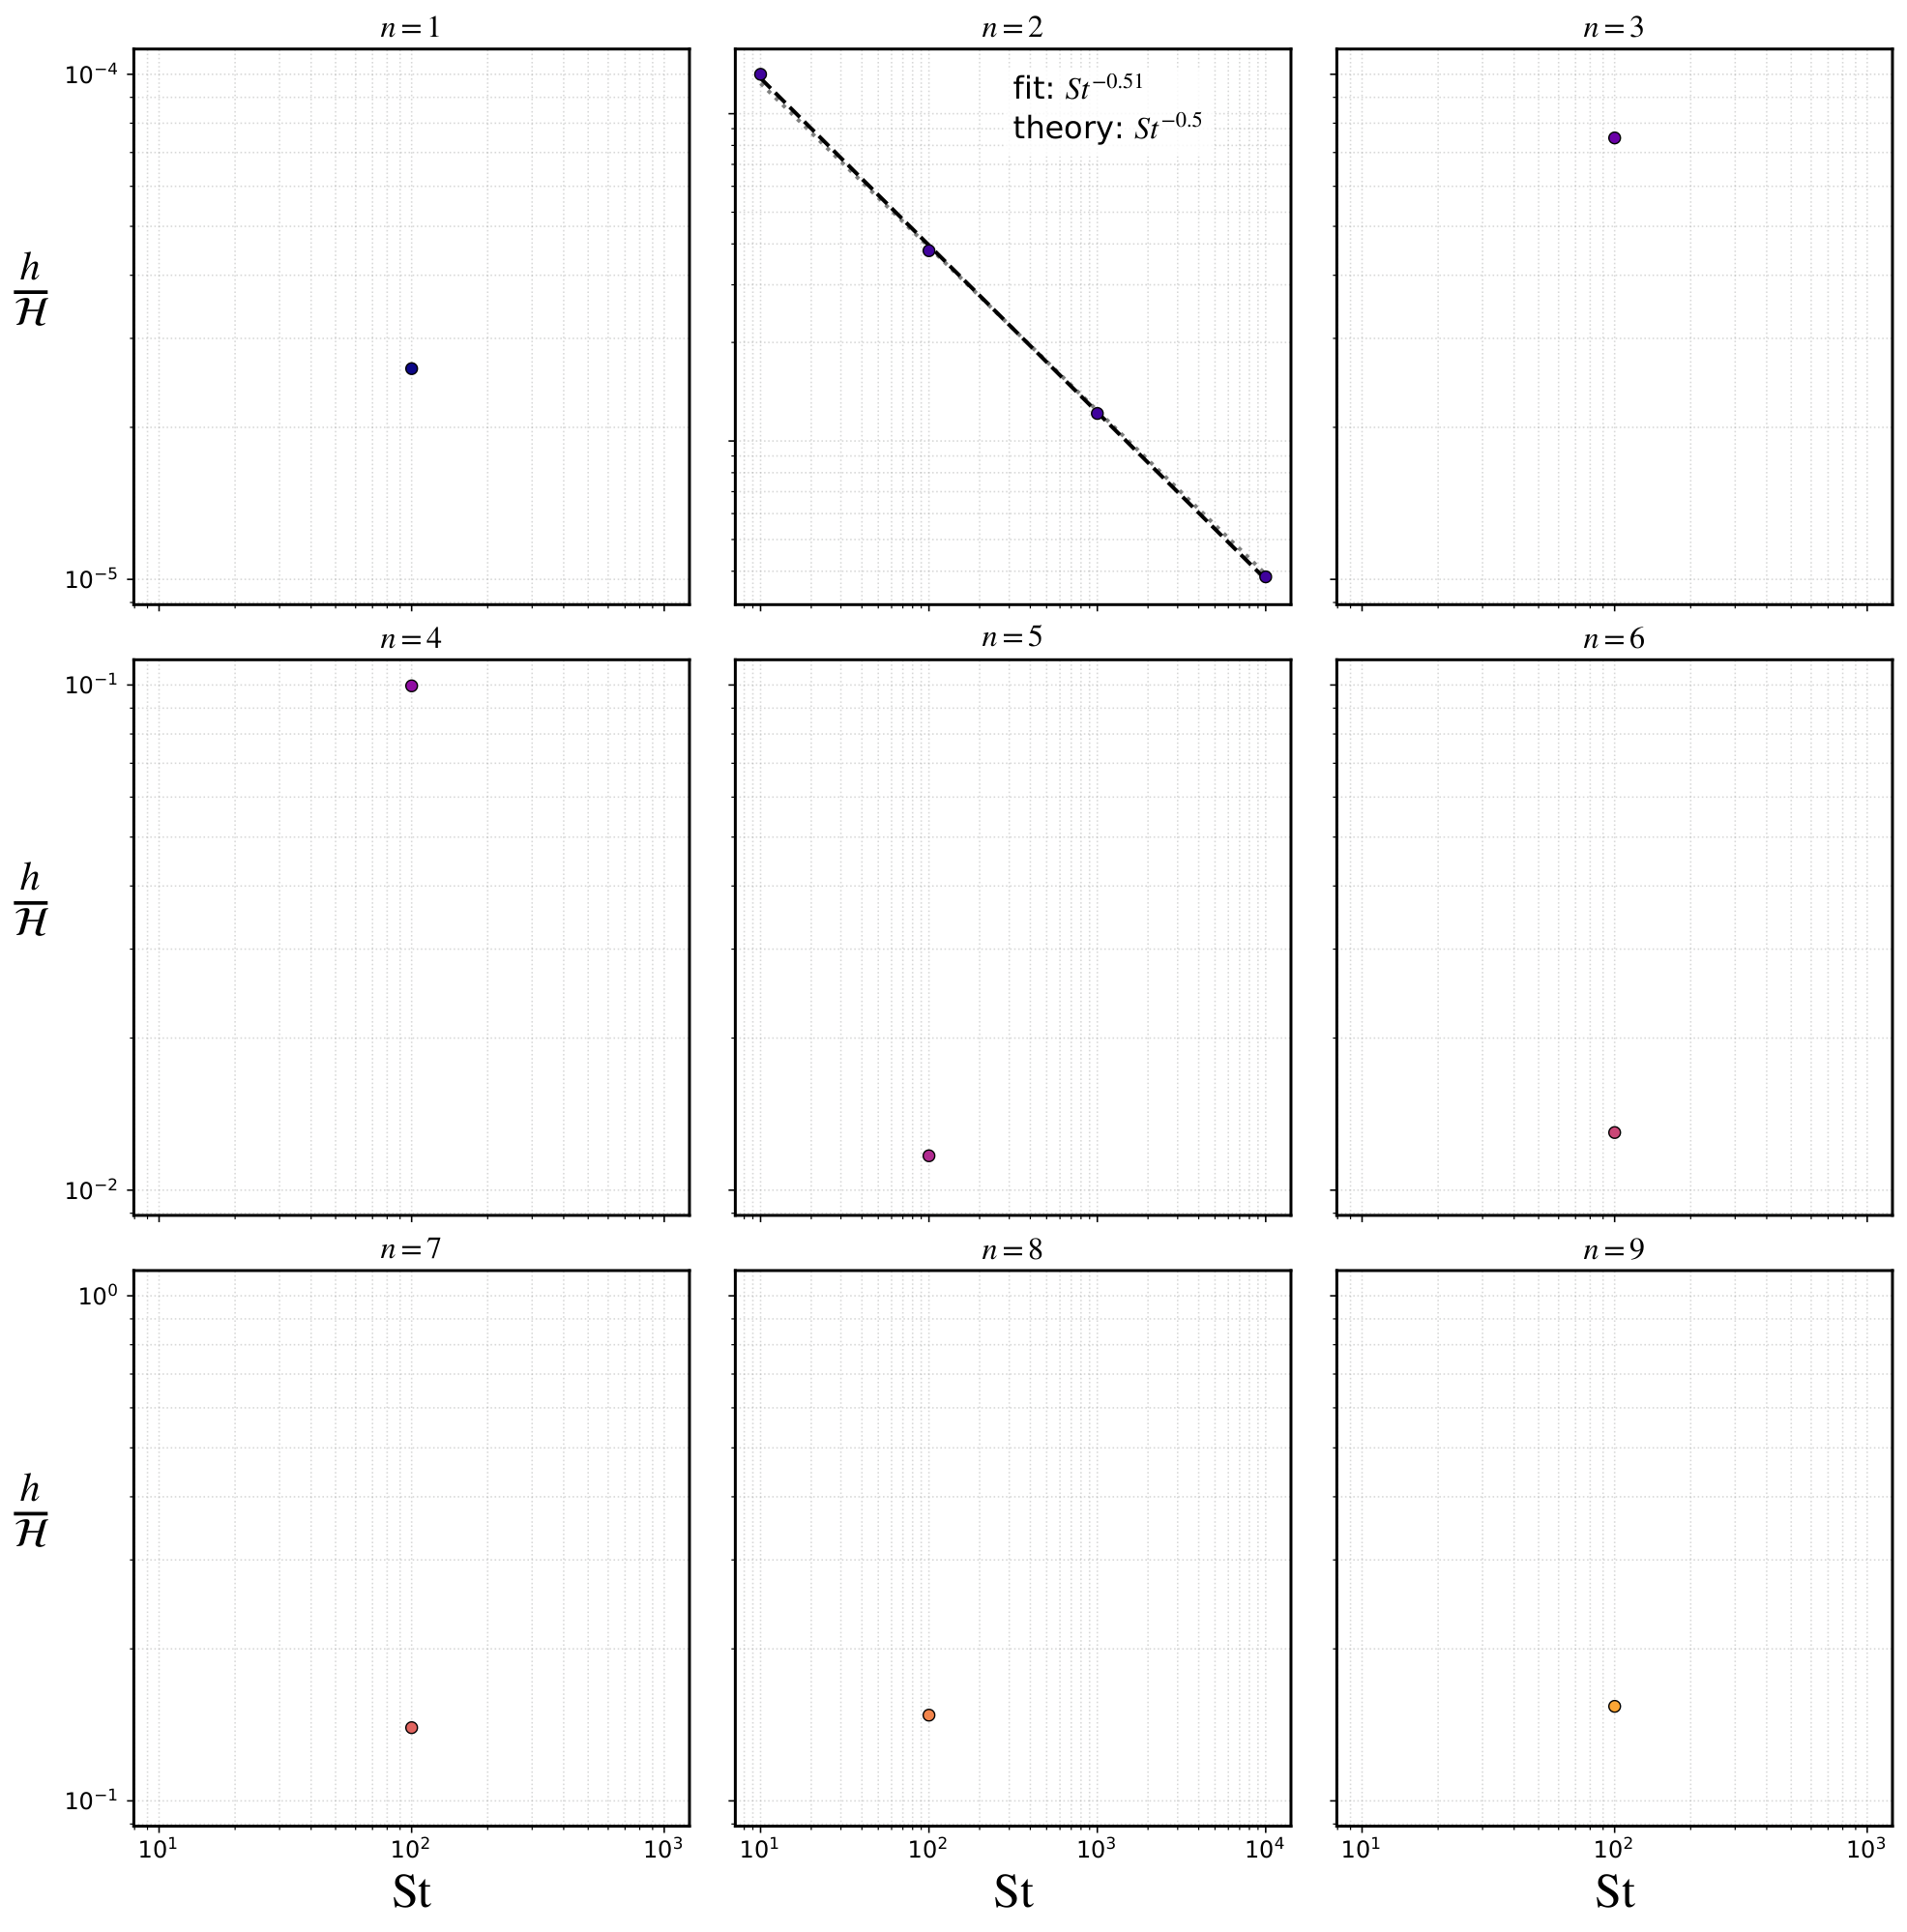

In [6]:
pdf = make_figure("fig_central_gap_scaling.py", "central_gap_scaling.pdf")
show_pdf(pdf)

## Central-gap scaling exponent

Fitted power-law exponent $-\alpha_{\rm center}(n)$ of the central gap at
mid-spread, compared with the theoretical prediction $-\alpha_{\rm center}=1/2$.


Saved: /home/aj/Desktop/Work/gpu-ehl-rest-coeff/paper/figures/output/exponent_summary.pdf


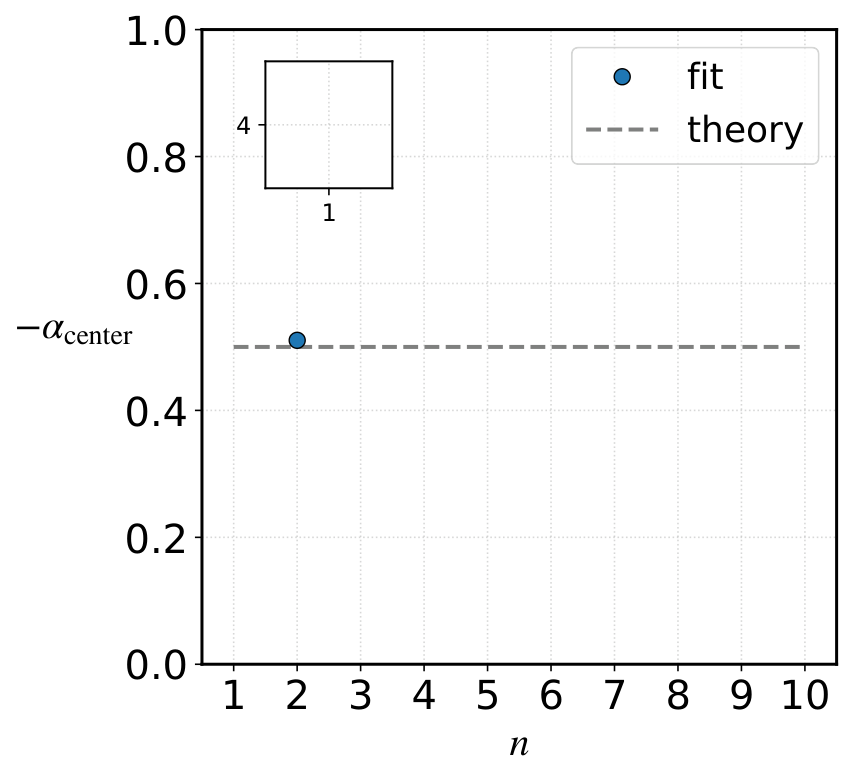

In [7]:
pdf = make_figure("fig_exponent_summary.py", "exponent_summary.pdf")
show_pdf(pdf)